Widget(value='<iframe src="http://localhost:60411/index.html?ui=P_0x245b25052b0_0&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:60411/index.html?ui=P_0x245c33b8550_1&reconnect=auto" class="pyvis…

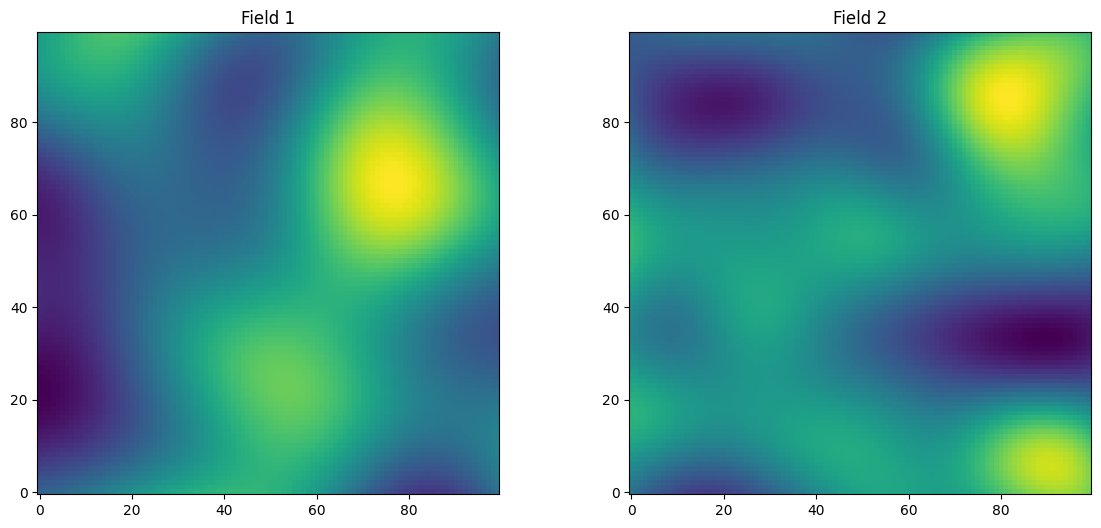

In [1]:
import numpy as np
import gstools as gs
import matplotlib.pyplot as plt
from scipy.ndimage import convolve



x=y = range(100)
model_1_2d = gs.Gaussian(dim=2, var=1, len_scale=[30, 30], angles=[0, 0])

model_2_2d = gs.Gaussian(dim=2, var=1, len_scale=[20, 20], angles=[np.pi/4, np.pi/4])



srf_1_2d = gs.SRF(model_1_2d)
srf_2_2d = gs.SRF(model_2_2d)


srf_1_2d((x,y), mesh_type='structured' , seed=0)
srf_2_2d((x,y), mesh_type='structured' , seed=1)


mesh_1_2d = srf_1_2d.to_pyvista() 
mesh_2_2d = srf_2_2d.to_pyvista() 
 

mesh_1_2d.contour(isosurfaces=50).plot()
mesh_2_2d.contour(isosurfaces=50).plot()

field_1_2d = srf_1_2d.field
field_2_2d = srf_2_2d.field


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(field_1_2d, cmap='viridis', origin='lower')
axes[0].set_title('Field 1')
axes[1].imshow(field_2_2d, cmap='viridis', origin='lower')
axes[1].set_title('Field 2')
plt.show()



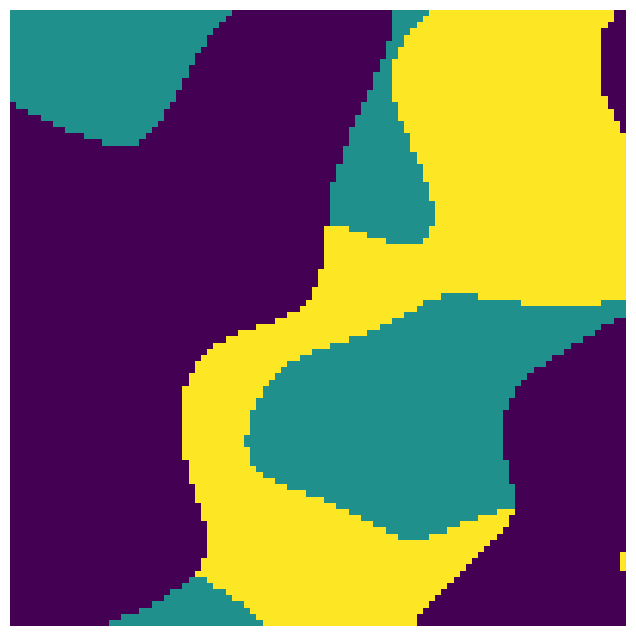

In [2]:
from scipy.stats import norm

granite_percent = 0.20
sandstone_percent = 0.50
quartz_percent = 0.30

cut_1 = norm.ppf(granite_percent)
cut_2 = norm.ppf(sandstone_percent/(quartz_percent + sandstone_percent))

lithotype_map = np.zeros((100, 100))
lithotype_map[(field_1_2d >= cut_1) & (field_2_2d < cut_2)] = 1
lithotype_map[(field_1_2d >= cut_1) & (field_2_2d >= cut_2)] = 2

plt.figure(figsize=(8,8))
plt.imshow(lithotype_map, cmap='viridis', origin='lower')
plt.axis('off')
plt.show()

C:\Users\barbe\AppData\Local\Temp\ipykernel_17664\4174689011.py:9: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  counts = np.bincount(neighbours, minlength=3)


Generation 10:
  Rock type 0: 78.8%
  Rock type 1: 6.3%
  Rock type 2: 14.9%
Generation 100:
  Rock type 0: 78.8%
  Rock type 1: 6.3%
  Rock type 2: 14.9%


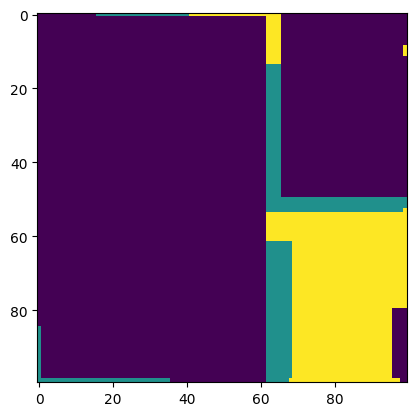

In [ ]:
checkpoints = [10, 100]

for generation in range(100):
    
    new_grid = lithotype_map.copy()
    for i in range(1, lithotype_map.shape[0]-1):
        for j in range(1, lithotype_map.shape[1]-1):
            neighbours = [lithotype_map[i-1, j], lithotype_map[i+1, j], lithotype_map[i, j-1], lithotype_map[i, j+1]]
            counts = np.bincount(neighbours, minlength=3)
            if counts.max() > 1:
                new_grid[i, j] = counts.argmax()
    lithotype_map = new_grid
    
    if generation+1 in checkpoints:
        total = lithotype_map.size
        print(f"Generation {generation+1}:")
        print(f"  Rock type 0: {(lithotype_map == 0).sum() / total * 100:.1f}%")
        print(f"  Rock type 1: {(lithotype_map == 1).sum() / total * 100:.1f}%")
        print(f"  Rock type 2: {(lithotype_map == 2).sum() / total * 100:.1f}%")

plt.imshow(lithotype_map, cmap='viridis')
plt.show()